# 第 11 章 · 悬崖行走探索策略代码实验

本页比较不同探索强度下的路径学习。悬崖边路线更短但风险更高，epsilon 越大，智能体越可能尝试随机动作。

[章节网页](../ch11.html)

## 运行内容

- 加载 CliffWalking-v0 环境
- 比较不同 epsilon
- 绘制回报与策略

## 0. 悬崖行走任务

训练曲线展示不同探索强度的回报，策略图展示最终学到的动作方向。把两张图合起来看，才能理解探索的代价。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 载入强化学习经典环境。
if importlib.util.find_spec("gymnasium") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gymnasium>=0.29"])

import gymnasium as gym

In [3]:
# CliffWalking-v0：在经典悬崖环境里比较不同 epsilon 的 SARSA。
def train_cliff_sarsa(epsilon, episodes=700, alpha=0.45, gamma=0.99, seed=0):
    env = gym.make("CliffWalking-v0")
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rows = []

    def choose_action(state):
        if rng.random() < epsilon:
            return env.action_space.sample()
        return int(np.argmax(Q[state]))

    for episode in range(1, episodes + 1):
        state, _ = env.reset(seed=seed + episode)
        action = choose_action(state)
        total_reward = 0
        steps = 0
        terminated = truncated = False
        while not (terminated or truncated) and steps < 200:
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_action = choose_action(next_state)
            target = reward + gamma * Q[next_state, next_action] * (not (terminated or truncated))
            Q[state, action] += alpha * (target - Q[state, action])
            state, action = next_state, next_action
            total_reward += reward
            steps += 1
        if episode % 50 == 0:
            rows.append({"epsilon": epsilon, "episode": episode, "reward": total_reward, "steps": steps})
    env.close()
    return pd.DataFrame(rows), Q


cliff_runs = []
cliff_tables = {}
for eps in [0.05, 0.10, 0.30]:
    trace, Q = train_cliff_sarsa(eps, seed=21)
    cliff_runs.append(trace)
    cliff_tables[eps] = Q

cliff_trace = pd.concat(cliff_runs, ignore_index=True)
display(cliff_trace.tail(12))

,epsilon,episode,reward,steps
30,0.3,150,-469,73
31,0.3,200,-187,88
32,0.3,250,-119,119
33,0.3,300,-49,49
34,0.3,350,-35,35
35,0.3,400,-32,32
36,0.3,450,-23,23
37,0.3,500,-24,24
38,0.3,550,-37,37
39,0.3,600,-125,26


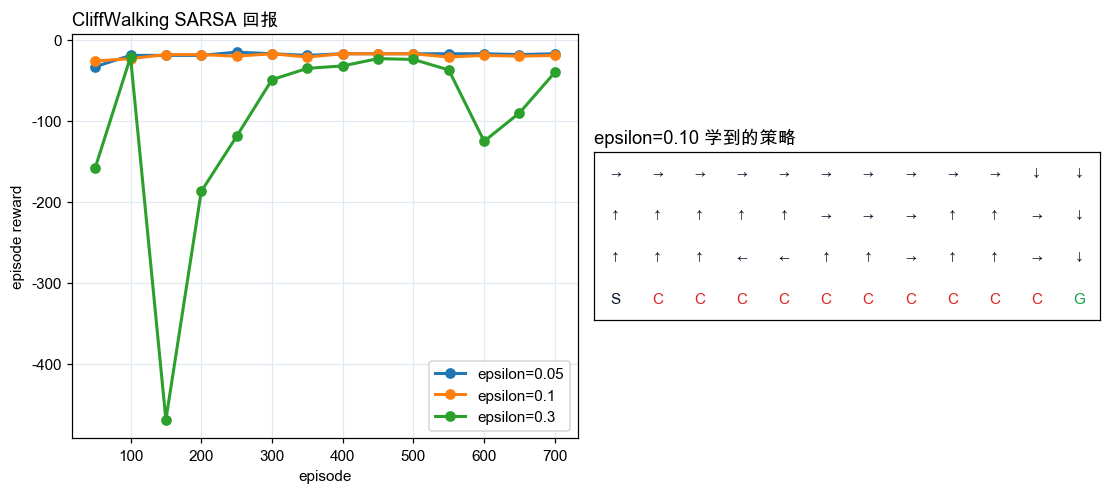

In [4]:
# 绘制 epsilon 对 CliffWalking 学习表现的影响。
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.6))
for epsilon, part in cliff_trace.groupby("epsilon"):
    axes[0].plot(part["episode"], part["reward"], marker="o", linewidth=2.0, label=f"epsilon={epsilon}")
axes[0].set_title("CliffWalking SARSA 回报", loc="left", fontweight="bold")
axes[0].set_xlabel("episode")
axes[0].set_ylabel("episode reward")
axes[0].grid(True, color="#e2e8f0", linewidth=0.8)
axes[0].legend()

best_eps = 0.10
policy = np.argmax(cliff_tables[best_eps], axis=1).reshape(4, 12)
arrow = {0: "↑", 1: "→", 2: "↓", 3: "←"}
grid = np.zeros((4, 12))
axes[1].imshow(grid, cmap="Greys", vmin=0, vmax=1)
for r in range(4):
    for c in range(12):
        if r == 3 and 1 <= c <= 10:
            text = "C"
            color = "#dc2626"
        elif (r, c) == (3, 0):
            text = "S"
            color = "#0f172a"
        elif (r, c) == (3, 11):
            text = "G"
            color = "#16a34a"
        else:
            text = arrow[int(policy[r, c])]
            color = "#0f172a"
        axes[1].text(c, r, text, ha="center", va="center", color=color, fontweight="bold")
axes[1].set_title("epsilon=0.10 学到的策略", loc="left", fontweight="bold")
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.tight_layout()
plt.show()